### 全维度特征体系构建

In [1]:
import pandas as pd
import numpy as np

# 读主表明细
MAIN_PATH = '/Users/neos/Desktop/Taobao DA/user_behavior_cleaned'
df = pd.read_parquet(MAIN_PATH)
print(f"主表: {df.shape}")
print(df.dtypes)
print(df.head())

主表: (6213379, 5)
time             datetime64[us]
user_id                 float64
item_id                 float64
item_category           float64
behavior_type           float64
dtype: object
                 time      user_id      item_id  item_category  behavior_type
0 2025-12-06 02:00:00   98047837.0  232431562.0         4245.0            1.0
1 2025-12-18 11:00:00   98607707.0   64749712.0         2883.0            1.0
2 2025-12-14 12:00:00  104221274.0  262661866.0         4370.0            1.0
3 2025-11-28 09:00:00  101260672.0  395905225.0        14018.0            1.0
4 2025-12-05 11:00:00  104811265.0  328893812.0         5894.0            1.0


In [2]:
#改数据类型
df['user_id'] = df['user_id'].astype('int64')
df['item_id'] = df['item_id'].astype('int64')
df['item_category'] = df['item_category'].astype('int64')
df['behavior_type'] = df['behavior_type'].astype('int8')

print(df.dtypes)

time             datetime64[us]
user_id                   int64
item_id                   int64
item_category             int64
behavior_type              int8
dtype: object


#### 1.用户生命周期特征

In [ ]:
活跃度等级：按用户总行为次数分档
低活用户：行为次数 ≤ 372（中位数以下，50%）
中活用户：372 < 行为次数 ≤ 1474（50%~90%，40%）
高活用户：行为次数 > 1474（90%以上，10%）

连续活跃天数：用户活跃日期序列中，最长的连续天数
流失间隔：以数据集的最后一天为基准，用户最后一次行为距今天数

In [3]:
# 提取用户-日期明细
df['date'] = df['time'].dt.date
user_dates = df.groupby(['user_id', 'date']).size().reset_index(name='cnt')
print(f"用户-日期记录数: {len(user_dates):,}")

# 活跃度等级 
user_total = df.groupby('user_id').size().reset_index(name='total_behavior')

def activity_level(x):
    if x <= 372:
        return '低活'
    elif x <= 1474:
        return '中活'
    else:
        return '高活'

user_total['活跃度等级'] = user_total['total_behavior'].apply(activity_level)
print("\n活跃度等级分布:")
print(user_total['活跃度等级'].value_counts())

# 连续活跃天数 
# 对每个用户的日期排序，计算连续段
user_dates['date'] = pd.to_datetime(user_dates['date'])
user_dates = user_dates.sort_values(['user_id', 'date'])

# 计算日期差，判断是否连续
user_dates['date_diff'] = user_dates.groupby('user_id')['date'].diff().dt.days

# 连续段的标记：date_diff不为1就是新段开始
user_dates['new_streak'] = ((user_dates['date_diff'] != 1) | user_dates['date_diff'].isna()).astype(int)
user_dates['streak_id'] = user_dates.groupby('user_id')['new_streak'].cumsum()

# 每个连续段的长度
streak_length = user_dates.groupby(['user_id', 'streak_id']).size().reset_index(name='streak_len')

# 每个用户的最长连续天数
max_streak = streak_length.groupby('user_id')['streak_len'].max().reset_index(name='连续活跃天数')

print("\n连续活跃天数统计:")
print(max_streak['连续活跃天数'].describe())

# 流失间隔 
# 数据集最后一天
max_date = df['time'].max()
print(f"\n数据集最后时间: {max_date}")

# 每个用户最后一次行为时间
user_last = df.groupby('user_id')['time'].max().reset_index(name='last_time')
user_last['流失间隔'] = (max_date - user_last['last_time']).dt.days

print("\n流失间隔统计:")
print(user_last['流失间隔'].describe())

# 合并
user_lifecycle = user_total[['user_id', '活跃度等级']].merge(
    max_streak, on='user_id', how='left'
).merge(
    user_last[['user_id', '流失间隔']], on='user_id', how='left'
)

print("\n用户生命周期特征表:")
print(user_lifecycle.head(10))
print(f"\n形状: {user_lifecycle.shape}")

用户-日期记录数: 202,324

活跃度等级分布:
活跃度等级
低活    5001
中活    4000
高活     999
Name: count, dtype: int64

连续活跃天数统计:
count    10000.000000
mean        11.344200
std          8.582639
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         31.000000
Name: 连续活跃天数, dtype: float64

数据集最后时间: 2025-12-18 23:00:00

流失间隔统计:
count    10000.000000
mean         1.270900
std          3.191259
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         30.000000
Name: 流失间隔, dtype: float64

用户生命周期特征表:
   user_id 活跃度等级  连续活跃天数  流失间隔
0     4913    中活      23     0
1     6118    低活       5     0
2     7528    低活       6     4
3     7591    低活       9     0
4    12645    低活       5     0
5    45368    低活       1    14
6    54056    低活       1    11
7    63348    低活       6     2
8    79824    低活      12     0
9    88930    中活       9     0

形状: (10000, 4)


#### 2.商品生命周期特征（不入模）

1. 热度衰减系数
商品热度会随时间衰减。规定前 15 天（11-18 ~ 12-02）为前期，后 16 天（12-03 ~ 12-18）为后期。计算方式：衰减系数 = 后期行为数 / 总行为数。

In [5]:
# 确定时间分界点：数据周期11-18到12-18，取中点12-03
cutoff_date = pd.Timestamp('2025-12-03')

# 商品总行为数
item_total = df.groupby('item_id').size().reset_index(name='total_behavior')

# 近期行为数（12-03之后）
item_recent = df[df['time'] >= cutoff_date].groupby('item_id').size().reset_index(name='recent_behavior')

# 合并
item_decay = item_total.merge(item_recent, on='item_id', how='left')
item_decay['recent_behavior'] = item_decay['recent_behavior'].fillna(0)

# 热度衰减系数
item_decay['热度衰减系数'] = item_decay['recent_behavior'] / item_decay['total_behavior']

item_decay = item_decay[['item_id', '热度衰减系数']]
print(f"\n商品数: {len(item_decay):,}")
print(item_decay.head(10))


商品数: 2,876,947
   item_id  热度衰减系数
0       64     0.0
1      496     0.0
2      528     0.0
3      579     1.0
4      581     1.0
5      668     0.4
6      703     1.0
7      869     0.0
8      936     0.5
9     1037     0.0


2. 类目竞争度
计算方式：类目竞争度 = 商品数 / 总行为数
值大：类目下商品多、但每个商品分别的行为少 → 竞争激烈、商品难出头
值小：类目下商品少、每个商品行为多 → 竞争小、容易获得流量

In [7]:
# 每个类目的商品数、总行为数
cat_stats = df.groupby('item_category').agg(
    商品数=('item_id', 'nunique'),
    总行为数=('behavior_type', 'size')
).reset_index()

cat_stats['类目竞争度'] = cat_stats['商品数'] / cat_stats['总行为数']

print("类目竞争度统计:")
print(cat_stats['类目竞争度'].describe())

print(f"\n类目数: {len(cat_stats):,}")
print("\n类目竞争度最高的10个类目:")
print(cat_stats.nlargest(10, '类目竞争度'))

类目竞争度统计:
count    8916.000000
mean        0.697147
std         0.213399
min         0.090909
25%         0.529410
50%         0.673652
75%         0.882353
max         1.000000
Name: 类目竞争度, dtype: float64

类目数: 8,916

类目竞争度最高的10个类目:
    item_category  商品数  总行为数  类目竞争度
0               2    1     1    1.0
1               3    2     2    1.0
2               4    1     1    1.0
3               6    8     8    1.0
14             23    1     1    1.0
16             25   21    21    1.0
17             26    1     1    1.0
22             33    1     1    1.0
25             40    1     1    1.0
30             54    1     1    1.0


这里发现竞争度为1的类目，很多是商品数和行为数都很小，比如该类目只有一个产品。后续考虑重新处理。

#### 3. 行为序列特征

 相邻行为间隔：同一用户相邻两次行为的时间差。针对每一个用户计算其平均相邻时间间隔，单位为小时。只有一个行为等用户记为0.

In [8]:
# 按用户和时间排序
df_sorted = df.sort_values(['user_id', 'time'])

# 计算每个用户相邻行为的时间差（单位：小时）
df_sorted['time_diff'] = df_sorted.groupby('user_id')['time'].diff().dt.total_seconds() / 3600

# 每个用户的平均间隔
user_interval = df_sorted.groupby('user_id')['time_diff'].mean().reset_index(name='平均行为间隔_小时')

print("平均行为间隔统计（小时）:")
print(user_interval['平均行为间隔_小时'].describe())

# 处理只有一个行为的用户（间隔为NaN，填0）
user_interval['平均行为间隔_小时'] = user_interval['平均行为间隔_小时'].fillna(0)

print(f"\n有间隔数据的用户数: {(user_interval['平均行为间隔_小时'] > 0).sum():,}")
print(f"只有一个行为的用户数: {(user_interval['平均行为间隔_小时'] == 0).sum():,}")

print("\n样例:")
print(user_interval.head(10))

平均行为间隔统计（小时）:
count    9992.000000
mean        3.773570
std         9.099513
min         0.000000
25%         0.853787
50%         1.729441
75%         3.730116
max       426.000000
Name: 平均行为间隔_小时, dtype: float64

有间隔数据的用户数: 9,953
只有一个行为的用户数: 47

样例:
   user_id  平均行为间隔_小时
0     4913   0.711220
1     6118  11.213115
2     7528   4.808696
3     7591   1.994429
4    12645   6.083333
5    45368  22.125000
6    54056  33.214286
7    63348   3.556962
8    79824   2.351613
9    88930   1.182553


#### 4.隐式特征挖掘

In [ ]:
SVD 隐式特征
首先为构建用户-商品交互矩阵，需先将用户对商品的多种行为（浏览、收藏、加购、购买）量化为统一的交互强度。
定义行为加权：购买（权重4） > 加购（3）> 收藏（2） > 浏览（1）。用户对某商品的交互强度为该用户对该商品所有行为的加权求和。

数据有1万用户 × 287万商品，矩阵较大且0值较多，因此采用稀疏存储，后续使用TruncatedSVD。
初步尝试50维隐向量下矩阵解释方差比综合为6%左右，很低，尝试100维隐向量，其矩阵解释方差比总和 = 0.0972，仍然低，信息损失较大。可能的原因是矩阵过大且过于稀疏。

In [11]:
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

# 1. 交互强度（行为加权）
behavior_weight = {1: 1, 2: 2, 3: 3, 4: 4}
df['weight'] = df['behavior_type'].map(behavior_weight)
interaction = df.groupby(['user_id', 'item_id'])['weight'].sum().reset_index()

# 2. 编码索引
user_ids = interaction['user_id'].unique()
item_ids = interaction['item_id'].unique()
user_map = {u: i for i, u in enumerate(user_ids)}
item_map = {it: j for j, it in enumerate(item_ids)}

# 3. 稀疏矩阵
rows = interaction['user_id'].map(user_map).values
cols = interaction['item_id'].map(item_map).values
data = interaction['weight'].values
R = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(item_ids)))

# 4. SVD，k=100
k = 100
svd = TruncatedSVD(n_components=k, random_state=42)
user_vectors = svd.fit_transform(R)
item_vectors = svd.components_.T

# 5. 转DataFrame
user_svd = pd.DataFrame(user_vectors, columns=[f'svd_user_{i}' for i in range(k)])
user_svd.insert(0, 'user_id', user_ids)

item_svd = pd.DataFrame(item_vectors, columns=[f'svd_item_{i}' for i in range(k)])
item_svd.insert(0, 'item_id', item_ids)

print(f"用户SVD表: {user_svd.shape}")
print(f"商品SVD表: {item_svd.shape}")
print(f"解释方差比总和: {svd.explained_variance_ratio_.sum():.4f}")

用户SVD表: (10000, 101)
商品SVD表: (2876947, 101)
解释方差比总和: 0.0972


In [ ]:
用户-商品交互特征
由于数据较大，计算负担较大，只选择以下特征：
交互类目数：用户交互过多少个类目，体现用户兴趣的广度

In [13]:
# 每个用户交互的商品数分布
user_item_count = df.groupby('user_id')['item_id'].nunique()
print("用户交互商品数分布:")
print(user_item_count.describe())
print(f"\n交互商品数最多的用户: {user_item_count.max()}")
print(f"交互商品数中位数: {user_item_count.median()}")

用户交互商品数分布:
count    10000.000000
mean       468.690400
std        590.000304
min          1.000000
25%        124.000000
50%        286.000000
75%        586.250000
max      14011.000000
Name: item_id, dtype: float64

交互商品数最多的用户: 14011
交互商品数中位数: 286.0


In [14]:
# ========== 用户兴趣集中度：交互类目数 ==========

user_cat_count = df.groupby('user_id')['item_category'].nunique().reset_index()
user_cat_count.columns = ['user_id', '交互类目数']

print("用户交互类目数特征:")
print(user_cat_count.head(10))
print(f"\n形状: {user_cat_count.shape}")
print(f"\n交互类目数统计:")
print(user_cat_count['交互类目数'].describe())

用户交互类目数特征:
   user_id  交互类目数
0     4913    121
1     6118     19
2     7528     12
3     7591     62
4    12645     40
5    45368      9
6    54056      3
7    63348     31
8    79824     69
9    88930    109

形状: (10000, 2)

交互类目数统计:
count    10000.000000
mean        90.074800
std         72.834727
min          1.000000
25%         38.000000
50%         72.000000
75%        122.000000
max       1131.000000
Name: 交互类目数, dtype: float64


RFM 用户价值分
R（Recency）：最近一次行为距数据集最后一天的天数
F（Frequency）：总行为次数
M（Monetary）：购买次数

全链路转化漏斗特征：浏览-加购､加购-收藏､收藏-购买各环节转化率

用户偏好强度得分
行为加权：购买（4）>加购（3）>收藏（2）>浏览（1）
计算方式：偏好强度得分 = 购买次数×4 + 加购次数×3 + 收藏次数×2 + 浏览次数×1

In [15]:
# 每个用户各行为次数 
user_behavior = df.groupby(['user_id', 'behavior_type']).size().unstack(fill_value=0).reset_index()
user_behavior.columns = ['user_id', '浏览', '收藏', '加购', '购买']

# RFM 
# R：最近一次行为距最后一天的天数
max_time = df['time'].max()
user_last = df.groupby('user_id')['time'].max().reset_index(name='last_time')
user_last['R'] = (max_time - user_last['last_time']).dt.days

# F：总行为次数
user_freq = df.groupby('user_id').size().reset_index(name='F')

# M：购买次数
user_m = user_behavior[['user_id', '购买']].rename(columns={'购买': 'M'})

rfm = user_last[['user_id', 'R']].merge(user_freq, on='user_id').merge(user_m, on='user_id')

# R越小越好，反转打分；F、M越大越好
rfm['R_score'] = pd.qcut(rfm['R'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM总分'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("RFM统计:")
print(rfm[['R', 'F', 'M', 'RFM总分']].describe())

# 全链路转化漏斗特征
funnel = user_behavior.copy()
funnel['浏览→加购'] = funnel['加购'] / funnel['浏览'].replace(0, np.nan)
funnel['加购→收藏'] = funnel['收藏'] / funnel['加购'].replace(0, np.nan)
funnel['收藏→购买'] = funnel['购买'] / funnel['收藏'].replace(0, np.nan)

# 处理除零：填0
funnel[['浏览→加购', '加购→收藏', '收藏→购买']] = funnel[['浏览→加购', '加购→收藏', '收藏→购买']].fillna(0)

print("\n漏斗特征统计:")
print(funnel[['浏览→加购', '加购→收藏', '收藏→购买']].describe())

#  用户偏好强度得分 
behavior_weight = {1: 1, 2: 2, 3: 3, 4: 4}
user_behavior['偏好强度得分'] = (
    user_behavior['浏览'] * 1 +
    user_behavior['收藏'] * 2 +
    user_behavior['加购'] * 3 +
    user_behavior['购买'] * 4
)

print("\n偏好强度得分统计:")
print(user_behavior['偏好强度得分'].describe())

print("\n三张特征表形状:")
print(f"RFM: {rfm.shape}")
print(f"漏斗: {funnel.shape}")
print(f"偏好: {user_behavior[['user_id', '偏好强度得分']].shape}")

RFM统计:
                  R             F             M         RFM总分
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       1.270900    621.337900     10.667800      9.000000
std        3.191259    788.498887     15.867628      3.334653
min        0.000000      1.000000      0.000000      3.000000
25%        0.000000    158.000000      2.000000      6.000000
50%        0.000000    372.000000      7.000000      9.000000
75%        1.000000    783.000000     14.000000     12.000000
max       30.000000  15936.000000    745.000000     15.000000

漏斗特征统计:
              浏览→加购         加购→收藏         收藏→购买
count  10000.000000  10000.000000  10000.000000
mean       0.062007      2.384600      2.068669
std        0.075140     10.421437      5.354564
min        0.000000      0.000000      0.000000
25%        0.010811      0.000000      0.000000
50%        0.040000      0.052632      0.185185
75%        0.089552      0.990652      1.571429
max        2.428571    249.000000    124.1

#### 5.输出特征数据集及特征字典

In [16]:
# 从各特征表取需要的列，统一按 user_id 合并
# 1. 用户生命周期
user_lifecycle_part = user_lifecycle[['user_id', '活跃度等级', '连续活跃天数', '流失间隔']]

# 2. 平均行为间隔
user_interval_part = user_interval[['user_id', '平均行为间隔_小时']]

# 3. 交互类目数
user_cat_part = user_cat_count[['user_id', '交互类目数']]

# 4. RFM
rfm_part = rfm[['user_id', 'R', 'F', 'M', 'R_score', 'F_score', 'M_score', 'RFM总分']]

# 5. 漏斗（含各行为次数 + 转化率）
funnel_part = funnel[['user_id', '浏览', '收藏', '加购', '购买', '浏览→加购', '加购→收藏', '收藏→购买']]

# 6. 偏好强度得分
pref_part = user_behavior[['user_id', '偏好强度得分']]

# 7. SVD用户隐向量
svd_part = user_svd  # 已含user_id

# 逐个合并
user_features = user_lifecycle_part
for part in [user_interval_part, user_cat_part, rfm_part, funnel_part, pref_part, svd_part]:
    user_features = user_features.merge(part, on='user_id', how='left')

print(f"用户特征宽表形状: {user_features.shape}")
print(f"总列数: {len(user_features.columns)}")
print(f"\n列名:")
print(user_features.columns.tolist())

用户特征宽表形状: (10000, 121)
总列数: 121

列名:
['user_id', '活跃度等级', '连续活跃天数', '流失间隔', '平均行为间隔_小时', '交互类目数', 'R', 'F', 'M', 'R_score', 'F_score', 'M_score', 'RFM总分', '浏览', '收藏', '加购', '购买', '浏览→加购', '加购→收藏', '收藏→购买', '偏好强度得分', 'svd_user_0', 'svd_user_1', 'svd_user_2', 'svd_user_3', 'svd_user_4', 'svd_user_5', 'svd_user_6', 'svd_user_7', 'svd_user_8', 'svd_user_9', 'svd_user_10', 'svd_user_11', 'svd_user_12', 'svd_user_13', 'svd_user_14', 'svd_user_15', 'svd_user_16', 'svd_user_17', 'svd_user_18', 'svd_user_19', 'svd_user_20', 'svd_user_21', 'svd_user_22', 'svd_user_23', 'svd_user_24', 'svd_user_25', 'svd_user_26', 'svd_user_27', 'svd_user_28', 'svd_user_29', 'svd_user_30', 'svd_user_31', 'svd_user_32', 'svd_user_33', 'svd_user_34', 'svd_user_35', 'svd_user_36', 'svd_user_37', 'svd_user_38', 'svd_user_39', 'svd_user_40', 'svd_user_41', 'svd_user_42', 'svd_user_43', 'svd_user_44', 'svd_user_45', 'svd_user_46', 'svd_user_47', 'svd_user_48', 'svd_user_49', 'svd_user_50', 'svd_user_51', 'svd_user_52',

In [28]:
# 导出用户特征宽表
output_path = '/Users/neos/Desktop/Taobao DA/user_features.parquet'
user_features.to_parquet(output_path, index=False)

In [48]:
# 特征字典 
feature_dict = pd.DataFrame({
    '特征类别': [
        '用户生命周期', '用户生命周期', '用户生命周期',
        '行为序列特征', '兴趣特征',
        'RFM', 'RFM', 'RFM', 'RFM', 'RFM', 'RFM', 'RFM',
        '行为次数', '行为次数', '行为次数', '行为次数',
        '转化漏斗', '转化漏斗', '转化漏斗',
        '偏好特征',
        'SVD隐式特征'
    ],
    '特征名': [
        '活跃度等级', '连续活跃天数', '流失间隔',
        '平均行为间隔/小时', '交互类目数',
        'R', 'F', 'M', 'R_score', 'F_score', 'M_score', 'RFM总分',
        '浏览', '收藏', '加购', '购买',
        '浏览→加购', '加购→收藏', '收藏→购买',
        '偏好强度得分',
        'svd_user_0 ~ svd_user_99'
    ],
    '含义': [
        '用户活跃程度分档', '用户最长连续活跃天数', '距最后一次行为的天数',
        '用户相邻行为的平均时间间隔', '用户交互过的类目数量',
        '最近一次行为距今天数', '行为频率', '购买次数（代金额）',
        'R的1-5分', 'F的1-5分', 'M的1-5分', '用户价值总分',
        '浏览次数', '收藏次数', '加购次数', '购买次数',
        '浏览到加购的转化率', '加购到收藏的转化率', '收藏到购买的转化率',
        '用户整体偏好强度',
        '用户隐向量（100维）'
    ],
    '计算方法': [
        '按总行为次数分档：≤372（50%分位）低活，372~1474（50%～90%分位）中活，>1474高活',
        '用户活跃日期序列中最长的连续自然日天数',
        '数据集最后一天 − 用户最后行为日期（天）',
        '用户按时间排序后相邻行为时间差的平均值（小时）',
        '该用户交互过的不同item_category去重计数',
        '数据集最后一天 − 用户最后行为日期',
        '用户总行为次数',
        '用户购买行为（behavior_type=4）次数',
        '按R分位数打分，越小得分越高',
        '按F分位数打分，越大得分越高',
        '按M分位数打分，越大得分越高',
        'R_score + F_score + M_score',
        'behavior_type=1的次数',
        'behavior_type=2的次数',
        'behavior_type=3的次数',
        'behavior_type=4的次数',
        '加购次数 / 浏览次数',
        '收藏次数 / 加购次数',
        '购买次数 / 收藏次数',
        '浏览×1 + 收藏×2 + 加购×3 + 购买×4',
        '基于用户-商品交互矩阵（行为加权：购买4/加购3/收藏2/浏览1），TruncatedSVD(k=100)分解'
    ]
})

pd.set_option('display.max_colwidth', None)
print(feature_dict.to_string(index=False))

   特征类别                      特征名            含义                                                    计算方法
 用户生命周期                    活跃度等级      用户活跃程度分档    按总行为次数分档：≤372（50%分位）低活，372~1474（50%～90%分位）中活，>1474高活
 用户生命周期                   连续活跃天数    用户最长连续活跃天数                                     用户活跃日期序列中最长的连续自然日天数
 用户生命周期                     流失间隔    距最后一次行为的天数                                   数据集最后一天 − 用户最后行为日期（天）
 行为序列特征                平均行为间隔/小时 用户相邻行为的平均时间间隔                                 用户按时间排序后相邻行为时间差的平均值（小时）
   兴趣特征                    交互类目数    用户交互过的类目数量                              该用户交互过的不同item_category去重计数
    RFM                        R    最近一次行为距今天数                                      数据集最后一天 − 用户最后行为日期
    RFM                        F          行为频率                                                 用户总行为次数
    RFM                        M     购买次数（代金额）                               用户购买行为（behavior_type=4）次数
    RFM                  R_score        R的1-5分                           

In [49]:
output_path = '/Users/neos/Desktop/Taobao DA/Feature_Dictionary.csv'
feature_dict.to_csv(output_path, index=False, encoding='utf-8-sig')

### 多维度探索性数据分析

基础行为分析

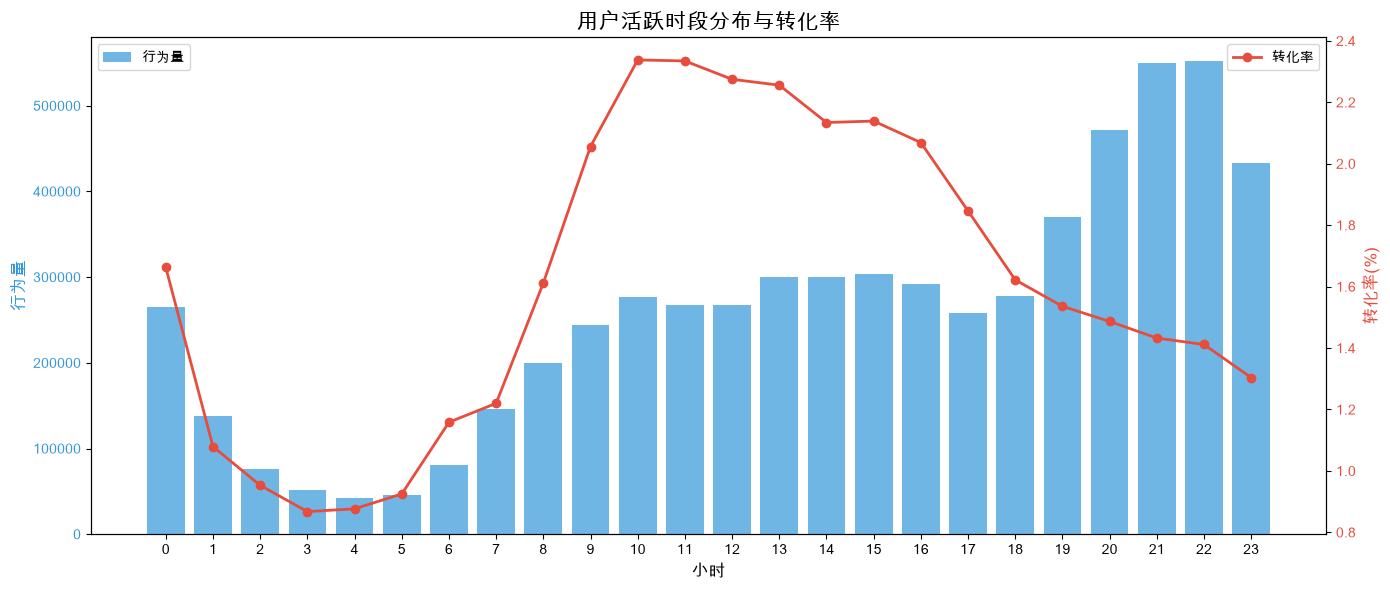

In [26]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 提取小时
df['hour'] = df['time'].dt.hour

# 各小时活跃行为量 
hour_activity = df.groupby('hour').size().reset_index(name='行为量')

# 各小时转化率（购买/总行为）
hour_total = df.groupby('hour').size().reset_index(name='总行为')
hour_buy = df[df['behavior_type'] == 4].groupby('hour').size().reset_index(name='购买数')
hour_conv = hour_total.merge(hour_buy, on='hour', how='left')
hour_conv['购买数'] = hour_conv['购买数'].fillna(0)
hour_conv['转化率'] = hour_conv['购买数'] / hour_conv['总行为'] * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# 柱状图：行为量
ax1.bar(hour_activity['hour'], hour_activity['行为量'], color='#3498DB', alpha=0.7, label='行为量')
ax1.set_xlabel('小时', fontsize=12)
ax1.set_ylabel('行为量', color='#3498DB', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498DB')
ax1.set_xticks(range(0, 24))

# 折线图：转化率（次坐标轴）
ax2 = ax1.twinx()
ax2.plot(hour_conv['hour'], hour_conv['转化率'], color='#E74C3C', marker='o', linewidth=2, label='转化率')
ax2.set_ylabel('转化率(%)', color='#E74C3C', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E74C3C')

plt.title('用户活跃时段分布与转化率', fontsize=16)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
用户活跃高峰期在晚上20-23点；早晨～中午时段活跃情况较稳定持平。用户最不活跃的时间在凌晨1～早晨7点。
转化率（购买/总行为）在10点达到峰值，随后缓慢降低，从16点开始明显下降。

由于淘宝app中收藏和加购实际上不存在先后关系（用户可能直接加购/购买而不收藏），为防止出现加购/购买用户数反而大于收藏数的情况，采用逐层筛选 + 递进，每一层要在上一层用户里进行筛选。可以看出浏览-收藏环节流失率最高，有收藏行为的用户大部分会选择加购，而已经加购的用户很大一部分会选择购买。

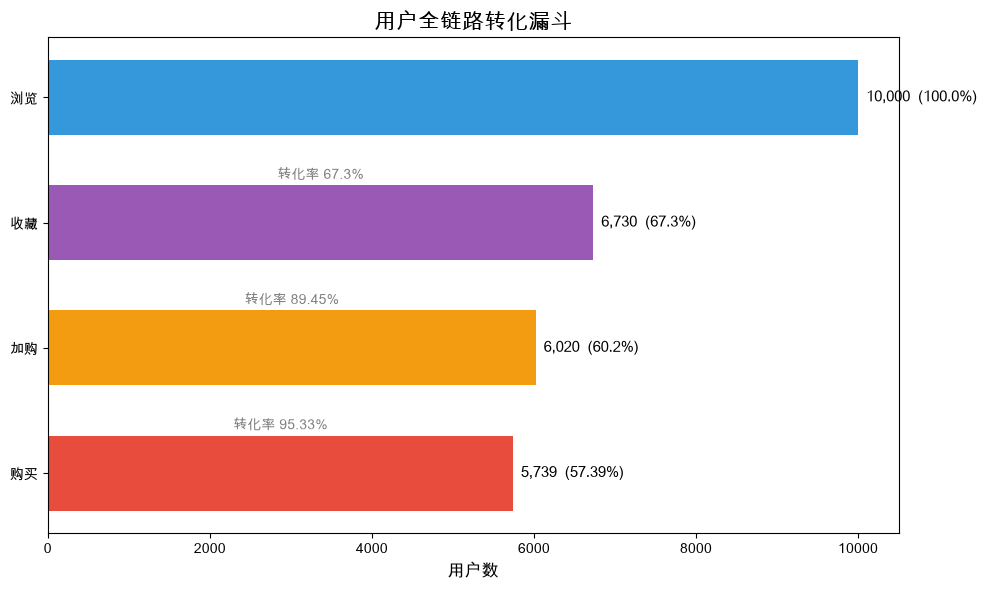

In [29]:
# 漏斗
behavior_map = {'浏览': 1, '收藏': 2, '加购': 3, '购买': 4}
behavior_chain = ['浏览', '收藏', '加购', '购买']

result = []
current_users = set(df['user_id'].unique())

for behavior in behavior_chain:
    bt = behavior_map[behavior]
    users_with_behavior = set(df[df['behavior_type'] == bt]['user_id'].unique())
    current_users = current_users & users_with_behavior
    result.append((behavior, len(current_users)))

funnel_df = pd.DataFrame(result, columns=['环节', '用户数'])

# 计算转化率和流失
funnel_df['环节转化率'] = (funnel_df['用户数'] / funnel_df['用户数'].shift(1) * 100).fillna(100).round(2)
funnel_df['整体转化率'] = (funnel_df['用户数'] / funnel_df['用户数'].iloc[0] * 100).round(2)
funnel_df['流失人数'] = (funnel_df['用户数'].shift(1) - funnel_df['用户数']).fillna(0).astype(int)



fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498DB', '#9B59B6', '#F39C12', '#E74C3C']
bars = ax.barh(funnel_df['环节'], funnel_df['用户数'], color=colors, height=0.6)
ax.set_xlabel('用户数', fontsize=12)
ax.set_title('用户全链路转化漏斗', fontsize=16)
ax.invert_yaxis()

# 柱子上标数值和整体转化率
for bar, v, pct in zip(bars, funnel_df['用户数'], funnel_df['整体转化率']):
    ax.text(v + max(funnel_df['用户数'])*0.01, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({pct}%)', va='center', fontsize=11)

# 标注相邻转化率
for i in range(1, len(funnel_df)):
    rate = funnel_df['环节转化率'].iloc[i]
    ax.text(funnel_df['用户数'].iloc[i]*0.5, i - 0.35,
            f'转化率 {rate}%', ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

用户分群分析

用户类型	R_score	F_score	M_score	含义
高价值	高（>=3）	高	高	最近活跃、频繁、购买多
潜力	高	低	低	最近活跃但行为少
流失	低	高	高	曾经活跃但现在不活跃
沉睡	低	低	低	长期不活跃、行为少

In [37]:
#  RFM用户分层 
def classify_user(row):
    r_high = row['R_score'] >= 3
    f_high = row['F_score'] >= 3
    m_high = row['M_score'] >= 3
    
    if r_high and f_high and m_high:
        return '高价值'
    elif r_high and not (f_high and m_high):
        return '潜力'
    elif not r_high and (f_high or m_high):
        return '流失'
    else:
        return '沉睡'

rfm['用户类型'] = rfm.apply(classify_user, axis=1)

print("用户类型分布:")
print(rfm['用户类型'].value_counts())
print(f"\n占比:")
print((rfm['用户类型'].value_counts(normalize=True) * 100).round(2))

用户类型分布:
用户类型
高价值    3561
潜力     2439
流失     2245
沉睡     1755
Name: count, dtype: int64

占比:
用户类型
高价值    35.61
潜力     24.39
流失     22.45
沉睡     17.55
Name: proportion, dtype: float64


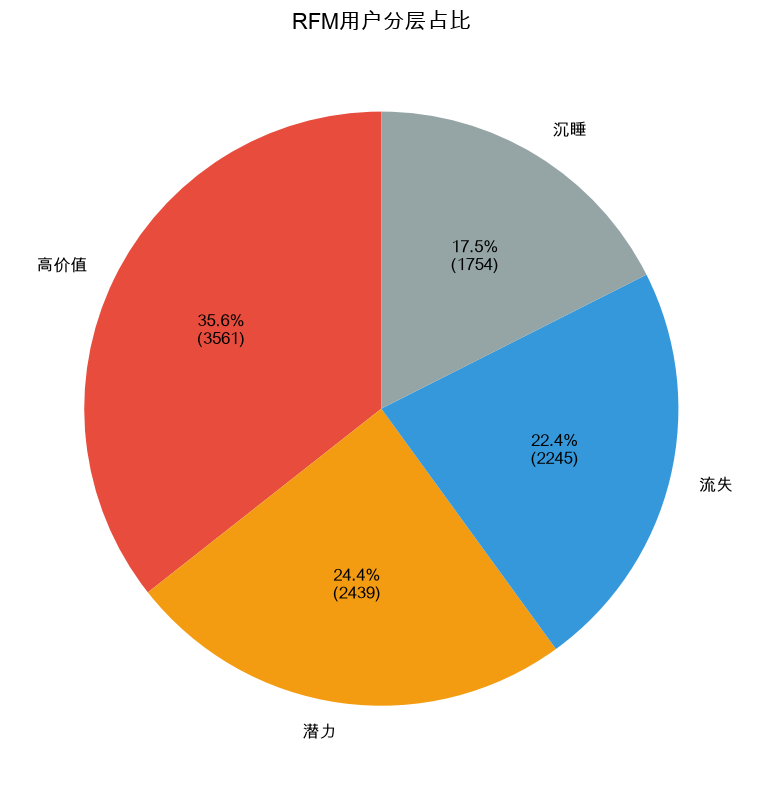

In [41]:
# 四类用户数量
type_counts = rfm['用户类型'].value_counts()

# 固定顺序
order = ['高价值', '潜力', '流失', '沉睡']
type_counts = type_counts.reindex(order)

# 画饼图
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#E74C3C', '#F39C12', '#3498DB', '#95A5A6']

wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(type_counts)/100)})',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)

ax.set_title('RFM用户分层占比', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
高价值用户占比35.6%，最多。其次是潜力用户，占比24.4%。流失用户占比22.4%，沉睡用户占比最小，为17.5%。

In [39]:
# ========== 2. 对比各群体行为特征与转化 ==========
# 把用户特征宽表与用户类型合并
user_features_rfm = user_features.merge(
    rfm[['user_id', '用户类型']], on='user_id', how='left'
)

# 各群体转化差异
# 用"购买次数 / 总行为次数"作为整体转化率
user_features_rfm['整体转化率'] = user_features_rfm['购买'] / user_features_rfm['F']

conversion_compare = user_features_rfm.groupby('用户类型').agg(
    用户数=('user_id', 'count'),
    平均购买次数=('购买', 'mean'),
    平均总行为=('F', 'mean'),
    整体转化率=('整体转化率', 'mean')
).round(3)

print("\n各群体转化差异:")
print(conversion_compare)


各群体转化差异:
       用户数  平均购买次数     平均总行为  整体转化率
用户类型                               
沉睡    1755   1.444    97.360  0.025
流失    2245  10.924   589.075  0.032
潜力    2439   4.033   350.100  0.024
高价值   3561  19.596  1085.691  0.023


各群体平均行为次数:
          浏览     收藏     加购     购买
用户类型                             
高价值   960.98  42.63  62.49  19.60
潜力    320.34  13.82  11.91   4.03
流失    523.70  22.15  32.30  10.92
沉睡     89.36   2.41   4.15   1.44


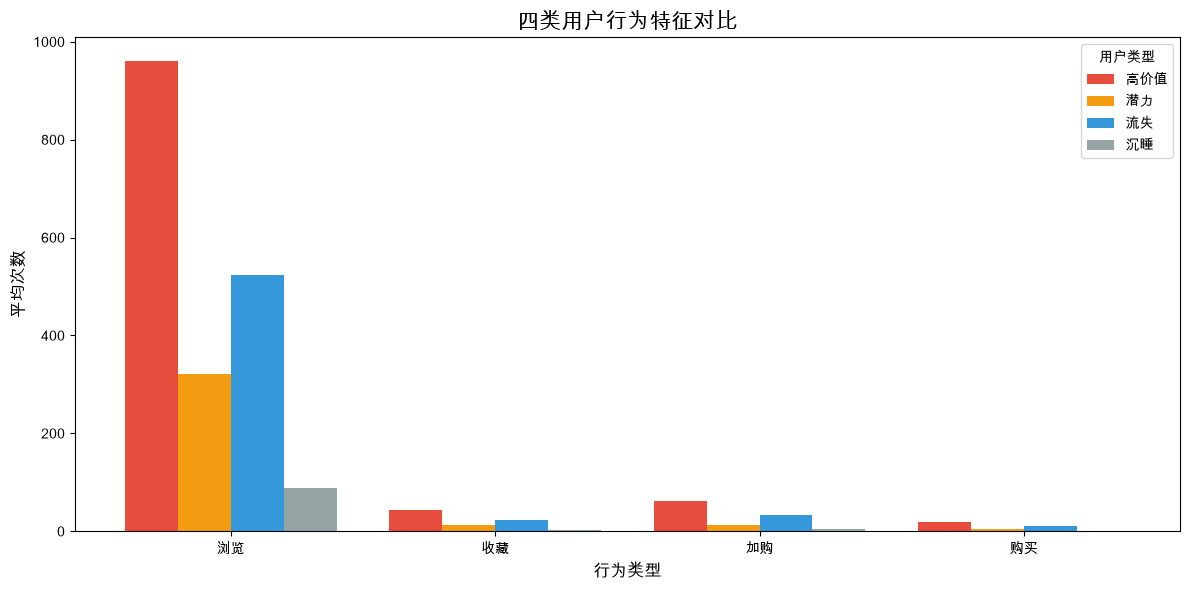

In [40]:
# 合并用户类型
merged = user_features.merge(rfm[['user_id', '用户类型']], on='user_id', how='left')

# 各群体在浏览/收藏/加购/购买上的平均次数
behaviors = ['浏览', '收藏', '加购', '购买']
group_avg = merged.groupby('用户类型')[behaviors].mean()

# 按固定顺序排列
order = ['高价值', '潜力', '流失', '沉睡']
group_avg = group_avg.loc[order]

print("各群体平均行为次数:")
print(group_avg.round(2))

# 画分组柱状图
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(behaviors))
width = 0.2
colors = ['#E74C3C', '#F39C12', '#3498DB', '#95A5A6']

for i, user_type in enumerate(order):
    values = group_avg.loc[user_type, behaviors].values
    ax.bar([p + i*width for p in x], values, width, label=user_type, color=colors[i])

ax.set_xlabel('行为类型', fontsize=12)
ax.set_ylabel('平均次数', fontsize=12)
ax.set_title('四类用户行为特征对比', fontsize=16)
ax.set_xticks([p + 1.5*width for p in x])
ax.set_xticklabels(behaviors)
ax.legend(title='用户类型')
plt.tight_layout()
plt.show()

In [ ]:
整体而言，流失用户的四类行为平均次数要高于潜力用户。潜力用户的加购次数小于收藏次数，其他三类用户都是加购次数大于收藏次数。

工作日日均: 201,530
周末日均: 197,272
双十二期间(12.11-12.13)日均: 266,604


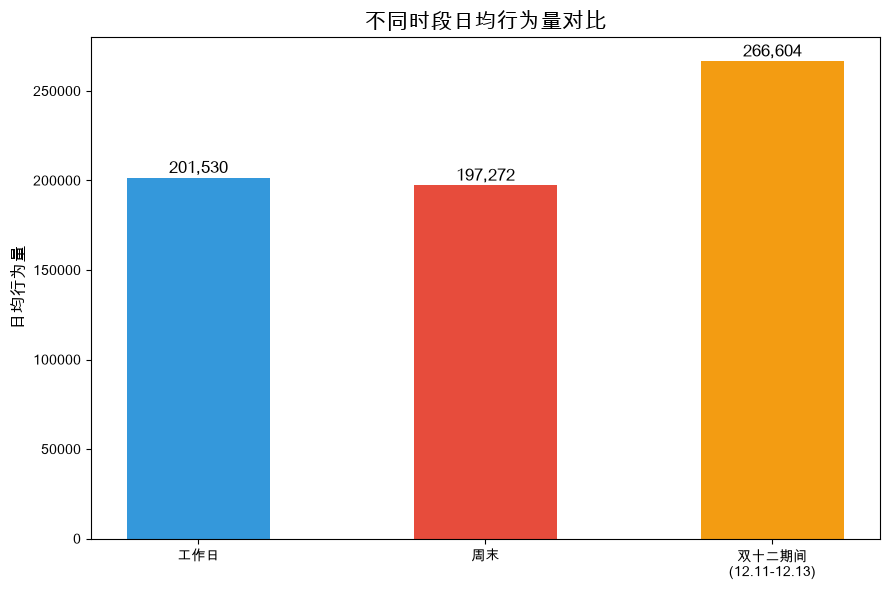

In [47]:
# 计算工作日/周末日均
all_dates = pd.to_datetime(pd.Series(df['date'].unique()))
weekend_days = all_dates[all_dates.dt.dayofweek.isin([5, 6])]
workday_days = all_dates[~all_dates.dt.dayofweek.isin([5, 6])]

workday_avg = df[~df['is_weekend']].shape[0] / len(workday_days)
weekend_avg = df[df['is_weekend']].shape[0] / len(weekend_days)

# 双十二期间（12.11-12.13）日均
d12_period = df[df['date'].astype(str).isin(['2025-12-11', '2025-12-12', '2025-12-13'])]
d12_avg = len(d12_period) / 3

print(f"工作日日均: {workday_avg:,.0f}")
print(f"周末日均: {weekend_avg:,.0f}")
print(f"双十二期间(12.11-12.13)日均: {d12_avg:,.0f}")

# 画柱状图
fig, ax = plt.subplots(figsize=(9, 6))
labels = ['工作日', '周末', '双十二期间\n(12.11-12.13)']
values = [workday_avg, weekend_avg, d12_avg]
colors = ['#3498DB', '#E74C3C', '#F39C12']

bars = ax.bar(labels, values, color=colors, width=0.5)
ax.set_ylabel('日均行为量', fontsize=12)
ax.set_title('不同时段日均行为量对比', fontsize=16)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(values)*0.01,
            f'{v:,.0f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
工作日和周末日均行为量较为接近，工作日行为量稍高，不排除是双十二当天为星期五的原因。双十二活动期间（12.11～12.13）日均活动量明显高出工作日和周末。